In [1]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

import matplotlib.pyplot as plt
import numpy as np



In [2]:


# Load Fashion MNIST Dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class Labels
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Dataset Shapes
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)



Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


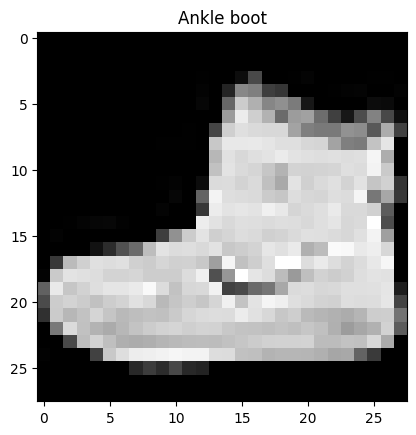

In [3]:
# Display First Image
plt.imshow(X_train[0], cmap='gray')
plt.title(labels[y_train[0]])
plt.show()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0



In [4]:
# Create Model
model = Sequential()

model.add(Input(shape=(28, 28)))

# Convert 2D image into 1D array
model.add(Flatten())

# Hidden Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))



2026-05-13 14:53:23.294182: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-13 14:53:23.294333: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-13 14:53:23.294344: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-13 14:53:23.294519: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-13 14:53:23.294533: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

102/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-05-13 14:53:23.744341: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted Label: T-shirt/top
Actual Label: Ankle boot


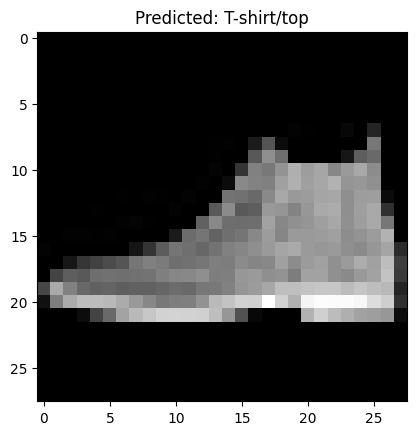

In [5]:


# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)





# Predictions
pred = model.predict(X_test)

# Show Prediction
print("Predicted Label:", labels[np.argmax(pred[0])])
print("Actual Label:", labels[y_test[0]])

# Display Predicted Image
plt.imshow(X_test[0], cmap='gray')
plt.title("Predicted: " + labels[np.argmax(pred[0])])
plt.show()

In [6]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7870 - loss: 0.6275 - val_accuracy: 0.8176 - val_loss: 0.5424
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8142 - loss: 0.5808 - val_accuracy: 0.8104 - val_loss: 0.5925
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8033 - loss: 0.7060 - val_accuracy: 0.8029 - val_loss: 0.7449
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7898 - loss: 0.9075 - val_accuracy: 0.7989 - val_loss: 0.9475
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7798 - loss: 1.2072 - val_accuracy: 0.7463 - val_loss: 1.5563
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7691 - loss: 1.6247 - val_accuracy: 0.7592 - val_loss: 1.8437
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7692 - loss: 2.0400 - val_accuracy: 0.7242 - val_loss: 3.1661
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7591 - loss: 2

In [7]:
# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7241 - loss: 5.0535
Test Accuracy: 0.7240999937057495


In [8]:
# Predictions
pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [9]:
# Show Prediction
print("Predicted Label:", labels[np.argmax(pred[0])])
print("Actual Label:", labels[y_test[0]])

Predicted Label: Ankle boot
Actual Label: Ankle boot


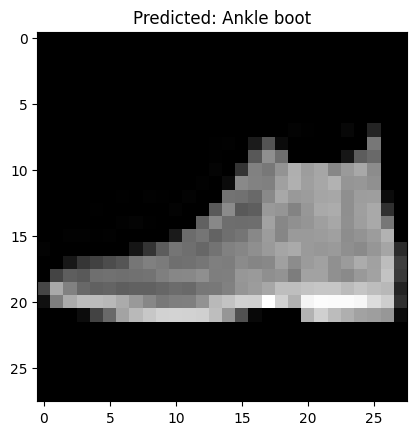

In [10]:
# Display Predicted Image
plt.imshow(X_test[0], cmap='gray')
plt.title("Predicted: " + labels[np.argmax(pred[0])])
plt.show()